### Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
import seaborn as sns

# import params
import functions.params_utils

### Setup

In [5]:
params = functions.params_utils.load_params()

GRANULARITY =  params["features"]["granularity"] # "W"
SEASONAL_PERIOD = 52 if GRANULARITY == "W" else 365

In [6]:
GCS_DIR = "gs://fashionmvforecast/data/input"
df = pd.read_csv(f"{GCS_DIR}/synthetic_fashion_demand.csv", parse_dates=["date"])

### Schema look

In [7]:
dupes = df.duplicated(subset=["sku_id", "date"]).sum()
print(f"duplicate (sku_id, date) rows: {dupes}")

print(df.dtypes)


duplicate (sku_id, date) rows: 0
sku_id                               str
date                      datetime64[us]
category                             str
sub_category                         str
color                                str
material                             str
brand                                str
gender                               str
size_range                           str
price                            float64
discount_pct                     float64
promo_flag                          bool
markdown_stage                       str
competitor_price_index           float64
week_of_year                       int64
month                              int64
quarter                            int64
is_holiday                          bool
is_weekend                          bool
fashion_week_flag                   bool
back_to_school_flag                 bool
payday_week_flag                    bool
days_since_launch                  int64
temperature             

### Missing data?

In [8]:
miss = df.isna().mean().sort_values(ascending=False)
print(miss[miss > 0])

Series([], dtype: float64)


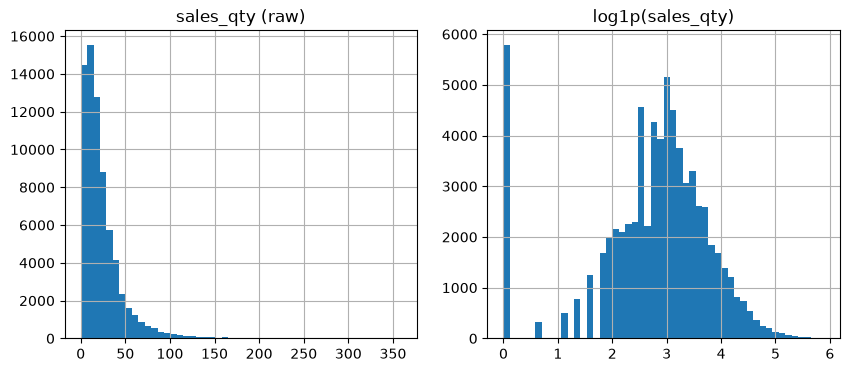

share of zero-sale (sku, period) rows: 8.20%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["sales_qty"].hist(bins=50, ax=axes[0])
axes[0].set_title("sales_qty (raw)")
np.log1p(df["sales_qty"]).hist(bins=50, ax=axes[1])
axes[1].set_title("log1p(sales_qty)")
plt.show()

zero_share = (df["sales_qty"] == 0).mean()
print(f"share of zero-sale (sku, period) rows: {zero_share:.2%}")

### Demand trendlines

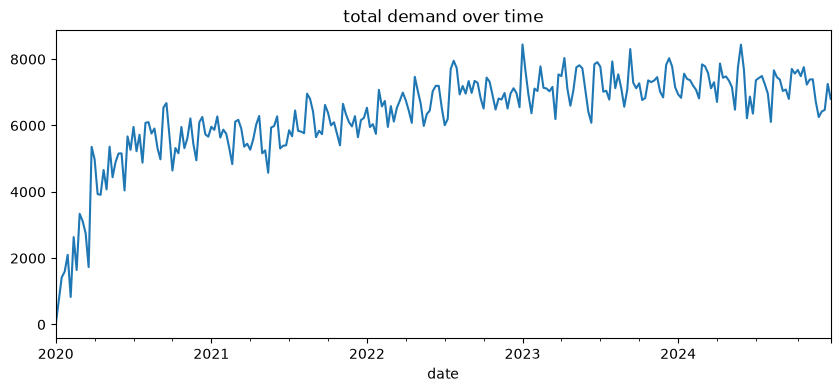

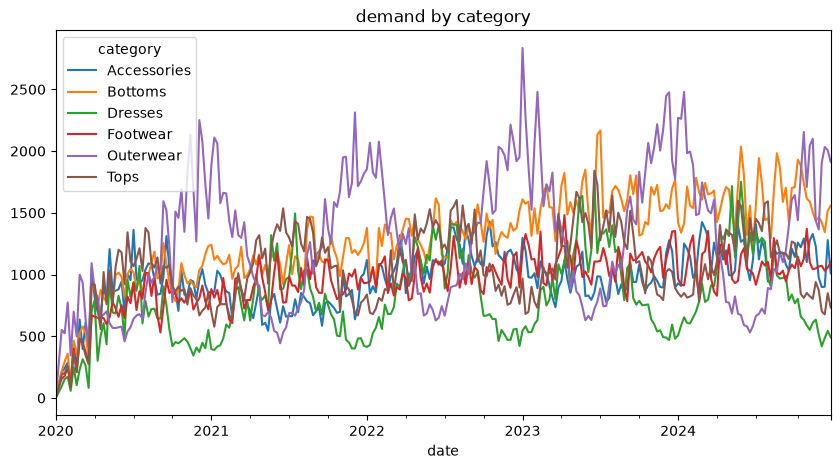

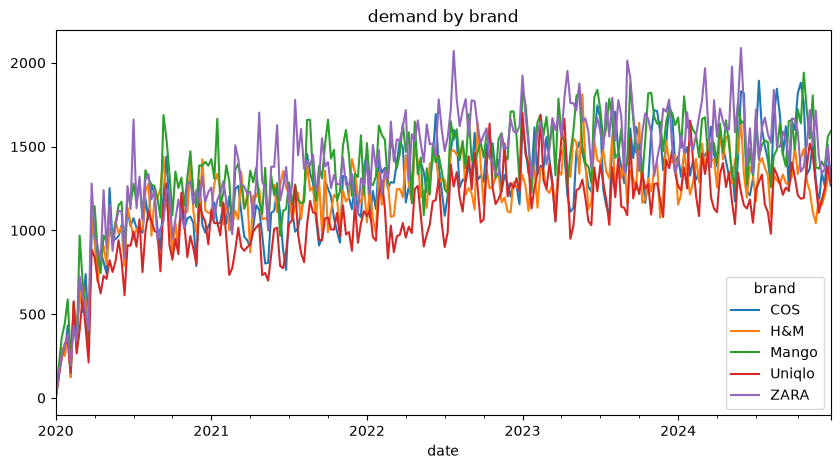

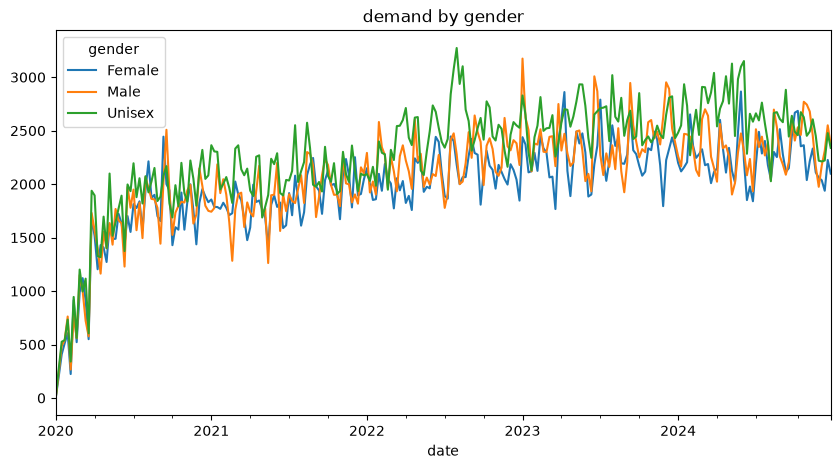

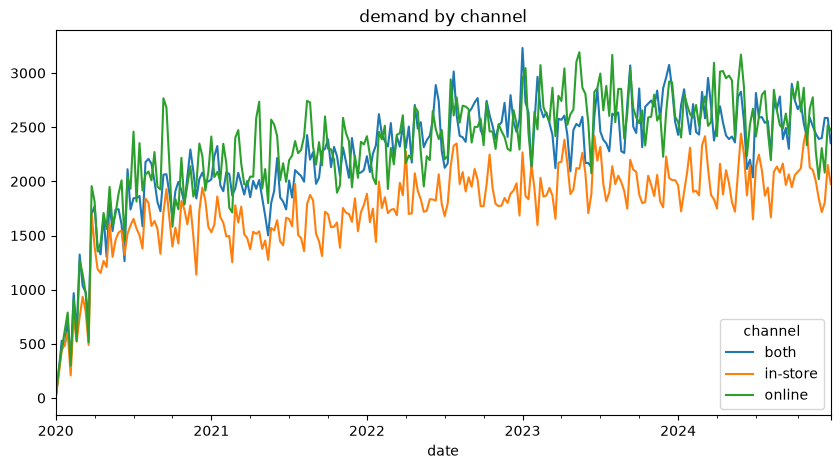

In [10]:
# total demand
agg = df.groupby("date")["sales_qty"].sum()
agg.plot(figsize=(10, 4), title="total demand over time")
plt.show()


# different seasonal shapes (e.g. swimwear vs. knitwear)
by_cat = df.groupby(["date", "category"])["sales_qty"].sum().unstack()
by_cat.plot(figsize=(10, 5), title="demand by category")
plt.show()

# different brands
by_br = df.groupby(["date", "brand"])["sales_qty"].sum().unstack()
by_br.plot(figsize=(10, 5), title="demand by brand")
plt.show()

# different gender
by_gen = df.groupby(["date", "gender"])["sales_qty"].sum().unstack()
by_gen.plot(figsize=(10, 5), title="demand by gender")
plt.show()

# different channels
by_ch = df.groupby(["date", "channel"])["sales_qty"].sum().unstack()
by_ch.plot(figsize=(10, 5), title="demand by channel")
plt.show()

### STL decomposition on one category's aggregate series into trend/seasonal/residual. 

STL decomposition for category: Tops


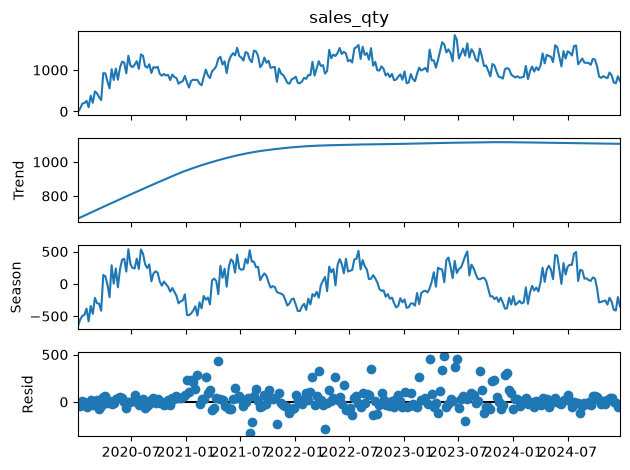

STL decomposition for category: Bottoms


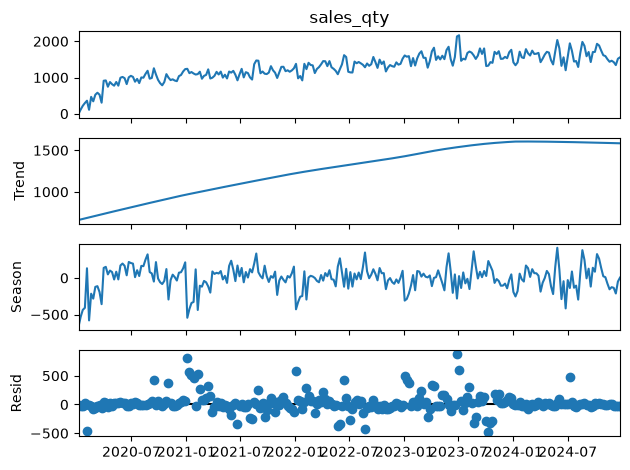

STL decomposition for category: Dresses


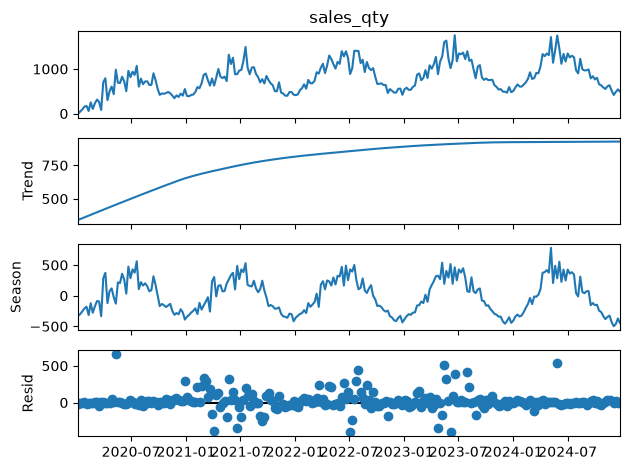

STL decomposition for category: Outerwear


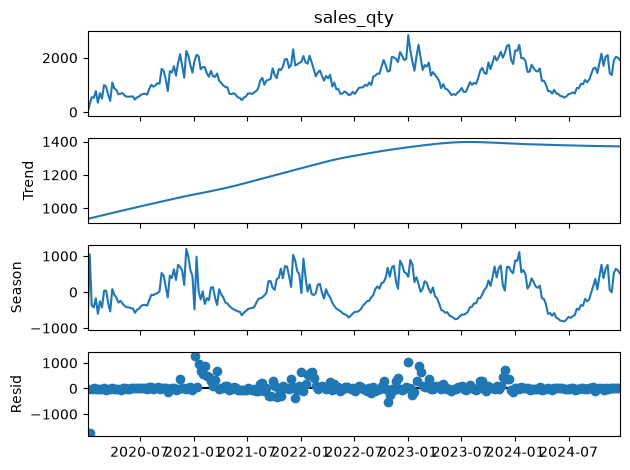

STL decomposition for category: Footwear


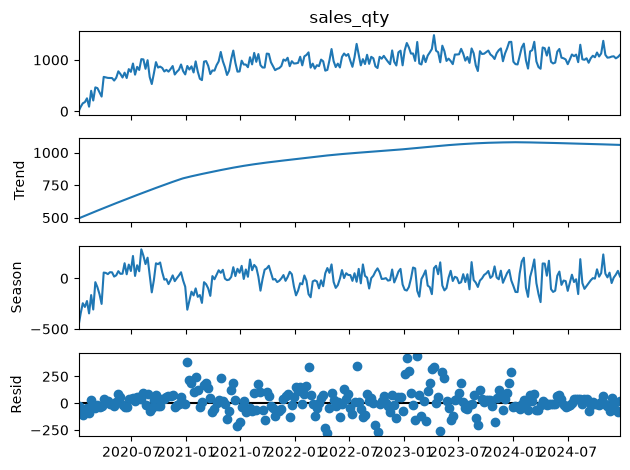

STL decomposition for category: Accessories


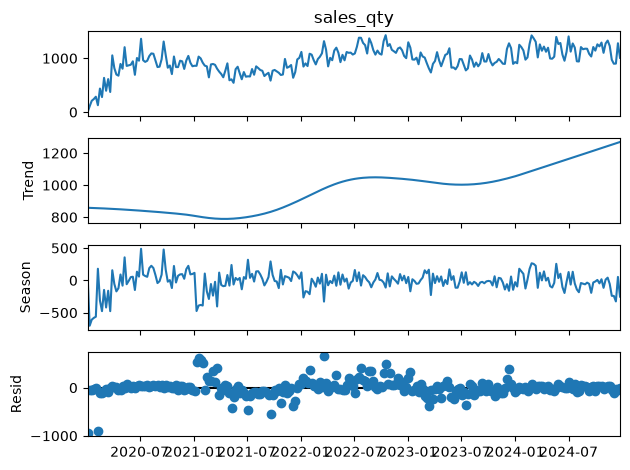

In [11]:
CATEGORIES = ["Tops", "Bottoms", "Dresses", "Outerwear", "Footwear", "Accessories"]

for category in CATEGORIES:
    print(f"STL decomposition for category: {category}")
    s = df[df["category"] == category].groupby("date")["sales_qty"].sum()
    result = STL(s, period=SEASONAL_PERIOD, robust=True).fit()
    title=f"sales qty by: {category}"
    result.plot()
    plt.show()

### stationarity and autocorrelation

ADF p-value (Tops): 0.0000  (< 0.05 => stationary)


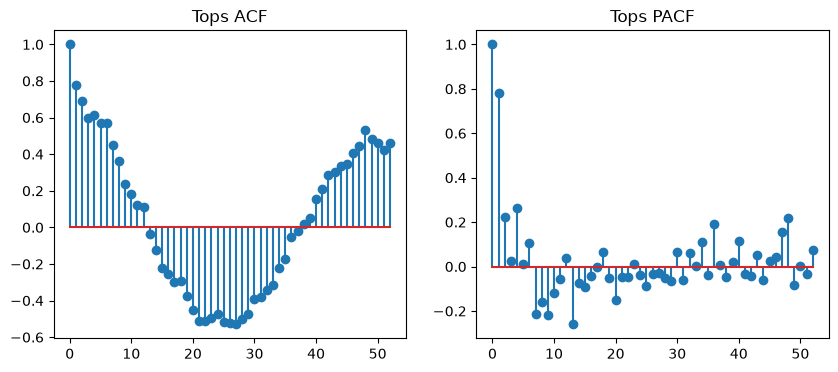

ADF p-value (Bottoms): 0.0052  (< 0.05 => stationary)


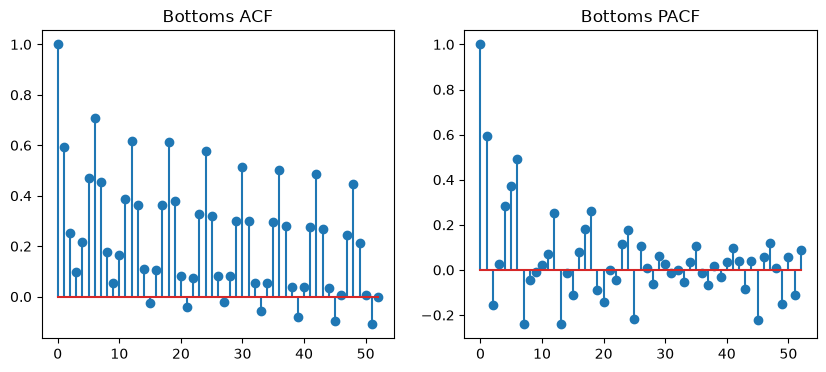

ADF p-value (Dresses): 0.0000  (< 0.05 => stationary)


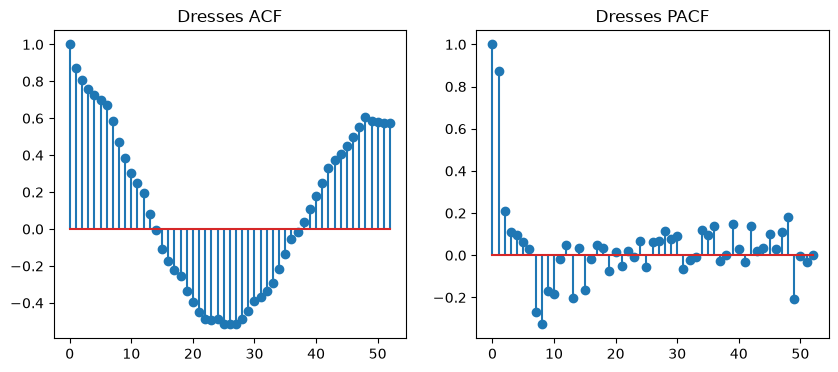

ADF p-value (Outerwear): 0.0000  (< 0.05 => stationary)


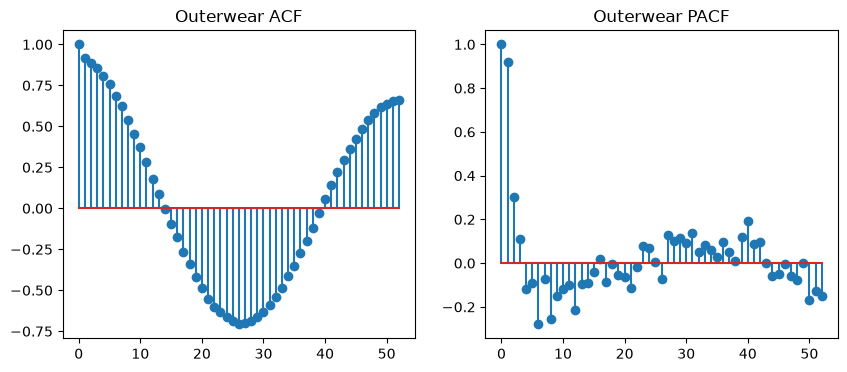

ADF p-value (Footwear): 0.0141  (< 0.05 => stationary)


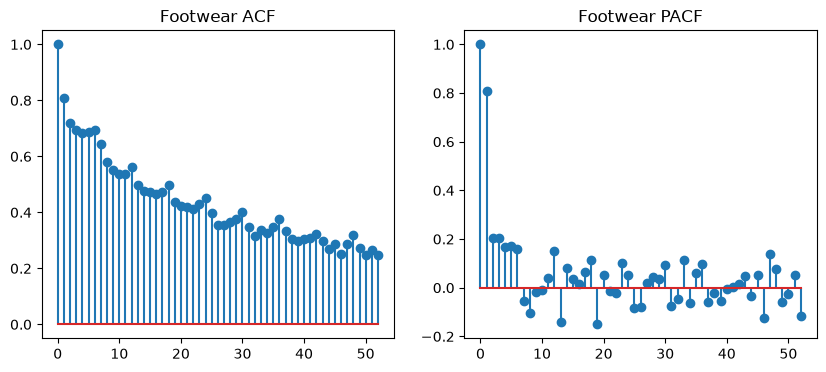

ADF p-value (Accessories): 0.1228  (< 0.05 => stationary)


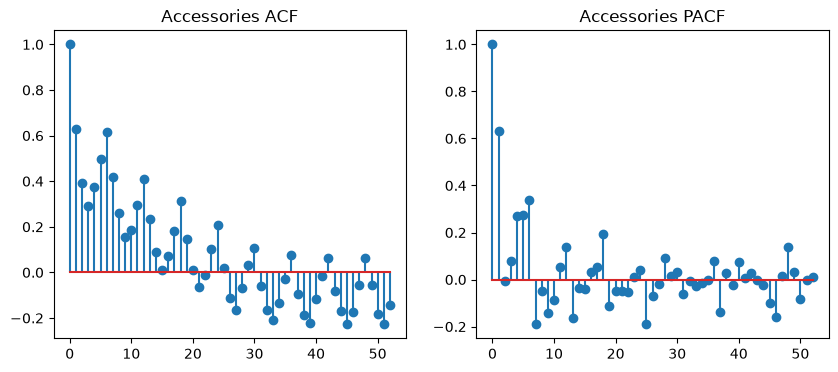

In [12]:
# ADF test tells you whether the series needs differencing before models
# that assume stationarity (e.g. classical ARIMA-family). ACF/PACF tell
# you which lags actually carry signal -- directly informs which lag
# features are worth engineering in step 2 of feature_engineering.py
# rather than guessing lag_1/lag_2/lag_52 blindly.

def stationarity_and_autocorrelation(df: pd.DataFrame, category: str) -> None:
    s = df[df["category"] == category].groupby("date")["sales_qty"].sum()
    adf_stat, p_value, *_ = adfuller(s.dropna())
    print(f"ADF p-value ({category}): {p_value:.4f}  (< 0.05 => stationary)")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].stem(acf(s.dropna(), nlags=SEASONAL_PERIOD))
    axes[0].set_title(category + " ACF")
    axes[1].stem(pacf(s.dropna(), nlags=SEASONAL_PERIOD))
    axes[1].set_title(category + " PACF")
    plt.show()


CATEGORIES = ["Tops", "Bottoms", "Dresses", "Outerwear", "Footwear", "Accessories"] 

for category in CATEGORIES:
    stationarity_and_autocorrelation(df, category=category)
    title=f"sales qty by: {category}"

### Regressors corelations

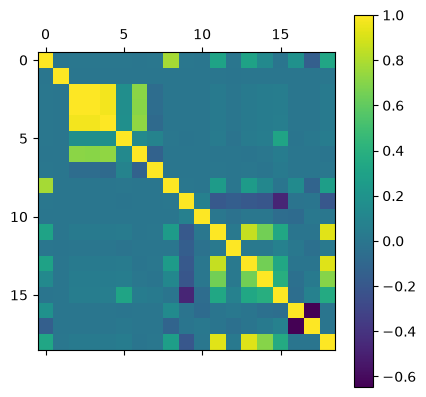

<Axes: >

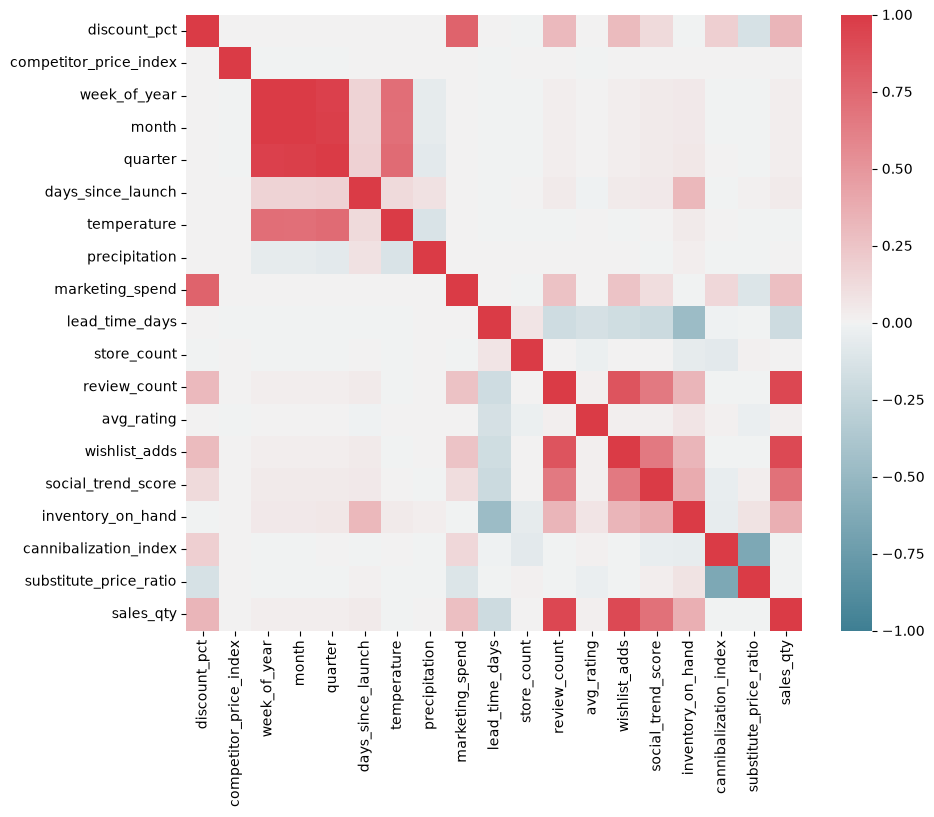

In [ ]:
def regressor_correlation(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=np.number).columns.drop(
        ["true_demand", "price"], errors="ignore"
    )
    return df[numeric_cols].corr()


corr_table = regressor_correlation(df)
#print(corr_table)


f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_table,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True, ax=ax)

### categorical_impact

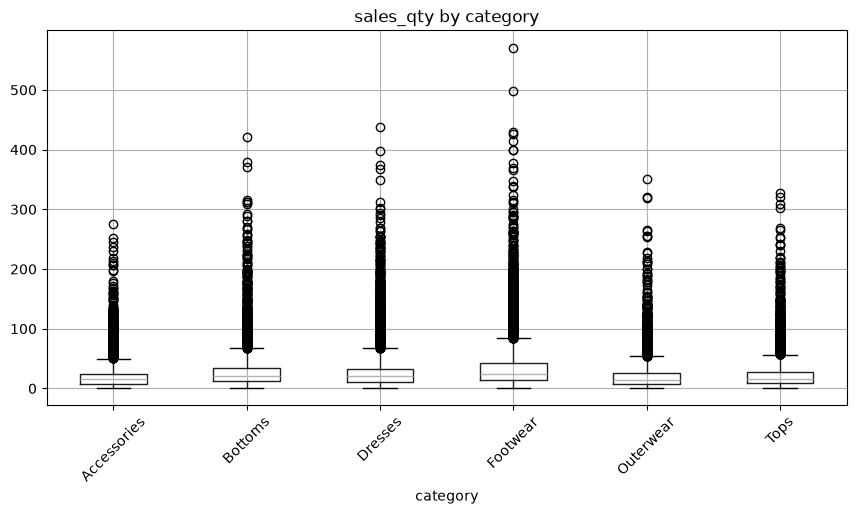

             count       mean  median
category                             
Accessories   8361  20.374836    15.0
Bottoms      10245  28.088531    21.0
Dresses      15318  26.960504    20.0
Footwear     15304  33.988761    25.0
Outerwear    11321  20.326915    14.0
Tops         11868  22.311510    16.0


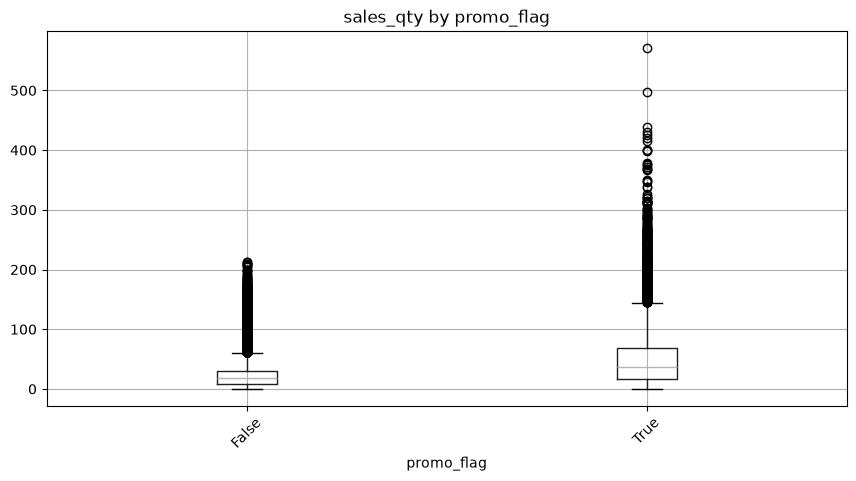

            count       mean  median
promo_flag                          
False       64161  22.755724    18.0
True         8256  51.617006    37.0


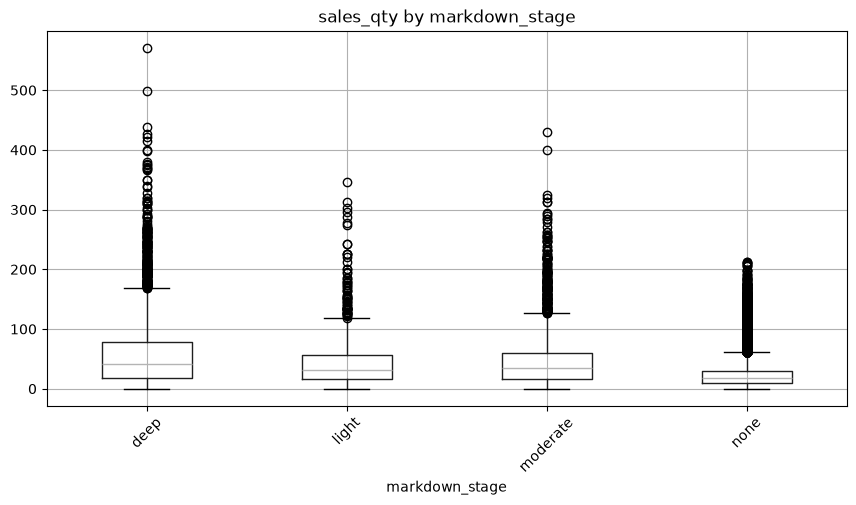

                count       mean  median
markdown_stage                          
deep             4137  57.745951    42.0
light            1019  43.692836    32.0
moderate         3100  46.042581    34.0
none            64161  22.755724    18.0


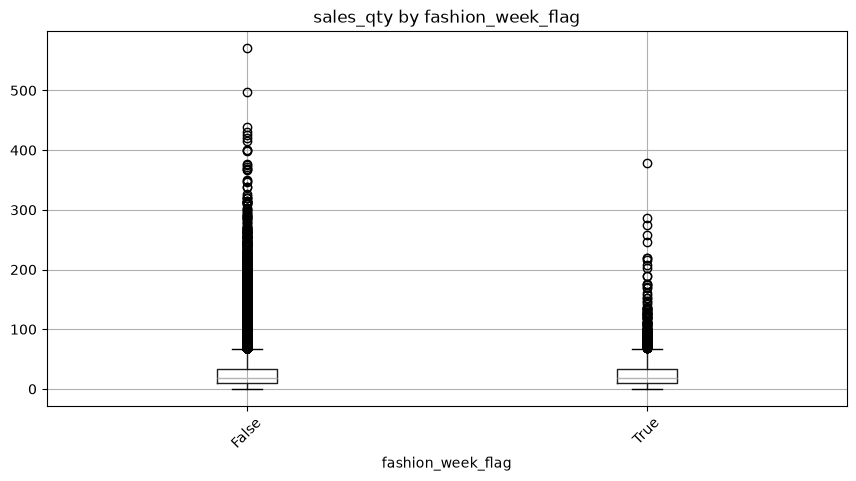

                   count       mean  median
fashion_week_flag                          
False              69639  26.038068    19.0
True                2778  26.247300    19.0


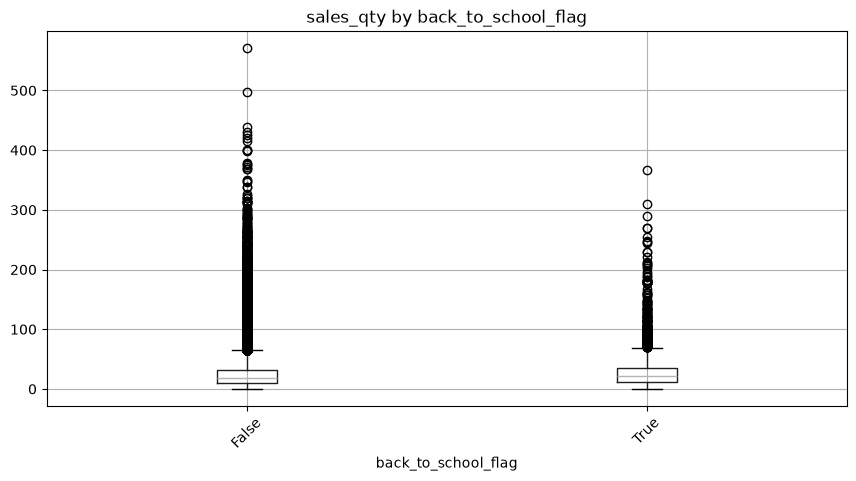

                     count       mean  median
back_to_school_flag                          
False                68229  25.855340    19.0
True                  4188  29.153773    21.0


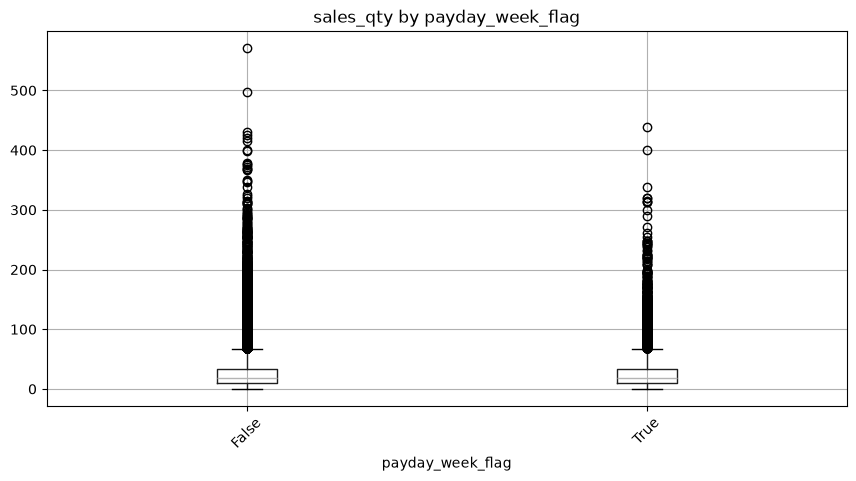

                  count       mean  median
payday_week_flag                          
False             55728  26.114036    19.0
True              16689  25.819222    19.0


In [ ]:
# Group-by comparison for categorical regressors (category, color, material, ...)
# boxplot of sales_qty per level.
def categorical_impact(df: pd.DataFrame, col: str) -> None:

    df.boxplot(column="sales_qty", by=col, rot=45, figsize=(10, 5))
    plt.title(f"sales_qty by {col}")
    plt.suptitle("")
    plt.show()

    print(df.groupby(col)["sales_qty"].agg(["count", "mean", "median"]))

# by category, color, material, etc. -- boxplot of sales_qty per level. Flags both real
for coll in ["category", "promo_flag", "markdown_stage", "fashion_week_flag", "back_to_school_flag", "payday_week_flag"]:
    categorical_impact(df, col=coll)




# POST FEATURES EDA AND FINDINGS


In [25]:
# new data with features engineered in step 2 of features.py

GCS_DIR = "gs://fashionmvforecast/data/input"
df = pd.read_csv(f"{GCS_DIR}/synthetic_fashion_demand_features.csv", parse_dates=["date"])

### Life cycle analysis

In [26]:
print(list(df.columns))

['sku_id', 'date', 'category', 'color', 'material', 'brand', 'size_range', 'price', 'discount_pct', 'promo_flag', 'markdown_stage', 'competitor_price_index', 'week_of_year', 'month', 'quarter', 'is_holiday', 'is_weekend', 'fashion_week_flag', 'back_to_school_flag', 'payday_week_flag', 'days_since_launch', 'temperature', 'precipitation', 'marketing_spend', 'campaign_flag', 'lead_time_days', 'store_count', 'channel', 'cannibalization_index', 'substitute_price_ratio', 'sales_qty', 'abc_class', 'xyz_class', 'woy_sin', 'woy_cos', 'month_sin', 'month_cos', 'lifecycle_stage', 'price_change_pct', 'relative_price_vs_category', 'had_promo', 'weeks_since_last_promo', 'sales_qty_lag_8', 'sales_qty_lag_9', 'sales_qty_lag_10', 'sales_qty_lag_12', 'sales_qty_lag_52', 'sales_qty_rollmean_4', 'sales_qty_rollstd_4', 'sales_qty_rollmean_12', 'sales_qty_rollstd_12', 'review_count_lag8', 'avg_rating_lag8', 'wishlist_adds_lag8', 'social_trend_score_lag8', 'inventory_on_hand_lag8', 'stockout_flag_lag8', 'sub

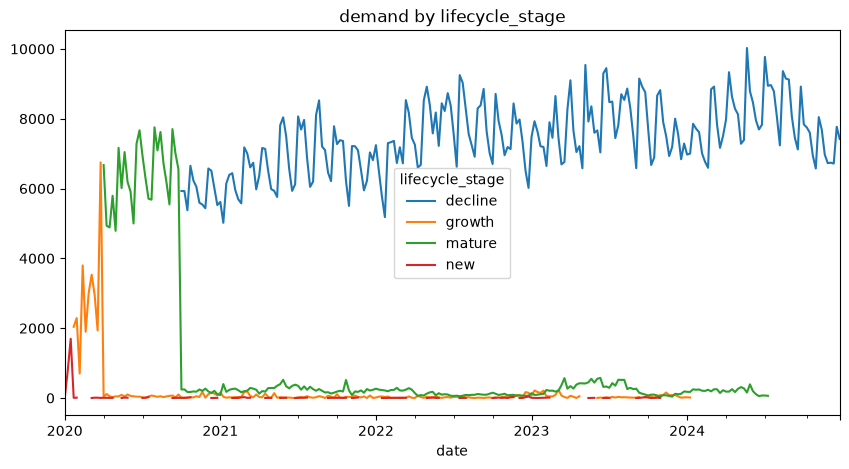

In [10]:
# labels = ["new", "growth", "mature", "decline"]

by_cat = df.groupby(["date", "lifecycle_stage"])["sales_qty"].sum().unstack()
by_cat.plot(figsize=(10, 5), title="demand by lifecycle_stage")
plt.show()


ABC/XYZ plots

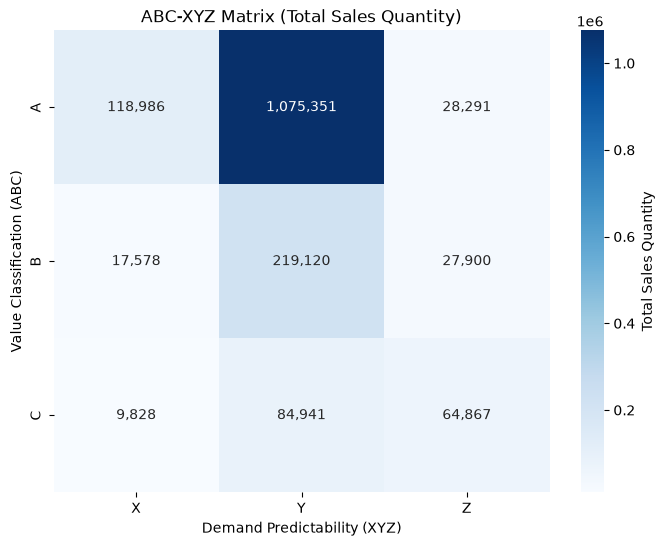

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate data into a 3x3 pivot table (added fill_value=0)
matrix_data = df.pivot_table(
    index="abc_class",
    columns="xyz_class",
    values="sales_qty",
    aggfunc="sum",
    fill_value=0,
)

# Optional: Map integer codes (1, 2, 3) to standard labels (A, B, C / X, Y, Z)
label_map_abc = {1: "A", 2: "B", 3: "C"}
label_map_xyz = {1: "X", 2: "Y", 3: "Z"}
matrix_data.index = [label_map_abc.get(i, i) for i in matrix_data.index]
matrix_data.columns = [label_map_xyz.get(i, i) for i in matrix_data.columns]

# 2. Render Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt=",.0f",  # Changed to floating-point display rounded to nearest whole number
    cmap="Blues",
    cbar_kws={"label": "Total Sales Quantity"},
)

plt.title("ABC-XYZ Matrix (Total Sales Quantity)")
plt.xlabel("Demand Predictability (XYZ)")
plt.ylabel("Value Classification (ABC)")
plt.show()

In [28]:
df.splits.unique()

<ArrowStringArray>
['TRAIN', 'VALIDATION', 'TEST']
Length: 3, dtype: str